In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.graphics.tsaplots import plot_acf,plot_pacf
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns
from scipy import signal
from scipy.signal import find_peaks
from scipy.signal import welch, find_peaks
from scipy.signal import butter, filtfilt
from scipy.stats import norm
from scipy.fft import fft
import scipy.signal as sig
import numpy as np
import warnings
warnings.filterwarnings('ignore')

In [2]:
def stock_finance(ticker='NVDA',periodo='2y'):
    stock=ticker
    df = yf.download(stock, period=periodo, interval="1d")
    if isinstance(df.columns, pd.MultiIndex):
        df.columns = df.columns.get_level_values(0)
    df['Returns'] = df['Close'].pct_change().dropna()
    df["MA_10"] = df["Close"].rolling(10).mean()
    df["MA_20"] = df["Close"].rolling(20).mean()
    df["MA_50"]=df["Close"].rolling(50).mean()
    df['MA_100']=df['Close'].rolling(100).mean()
    df["Volatility"] = df["Returns"].rolling(20).std()
    df["Cumulative_Returns"] = (1 + df["Returns"]).cumprod()
    df["Volume_Norm"] = df["Volume"] / df["Volume"].max()
    df['Stock']=stock
    df["BB_Middle"] = df["Close"].rolling(20).mean()
    df["BB_Std"] = df["Close"].rolling(20).std()
    df["BB_Upper"] = df["BB_Middle"] + 2 * df["BB_Std"]
    df["BB_Lower"] = df["BB_Middle"] - 2 * df["BB_Std"]
    return df

def compute_rsi(data, window=14):
    delta = data.diff()

    gain = (delta.where(delta > 0, 0)).rolling(window).mean()
    loss = (-delta.where(delta < 0, 0)).rolling(window).mean()

    rs = gain / loss
    rsi = 100 - (100 / (1 + rs))

    return rsi

def compute_macd(df, fast=12, slow=26, signal=9):
    ema_fast = df["Close"].ewm(span=fast, adjust=False).mean()
    ema_slow = df["Close"].ewm(span=slow, adjust=False).mean()

    macd = ema_fast - ema_slow
    signal_line = macd.ewm(span=signal, adjust=False).mean()
    hist = macd - signal_line

    return macd, signal_line, hist

In [3]:
df=stock_finance(ticker='NVDA',periodo='2y')
df["MACD"], df["MACD_Signal"], df["MACD_Hist"] = compute_macd(df)
df["RSI"] = compute_rsi(df["Close"], 14)
df["Buy_Signal"] = (df["RSI"] < 30) & (df["Close"] < df["BB_Lower"])
df["Sell_Signal"] = (df["RSI"] > 70) & (df["Close"] > df["BB_Upper"])

[*********************100%***********************]  1 of 1 completed


In [4]:
features = [
    'Close',
    'High',
    'Low',
    'Open',
    'Volume',
    'Returns',
    'MA_10',
    'MA_20',
    'MA_50',
    'MA_100',
    'Volatility',
    'Cumulative_Returns',
    'Volume_Norm',
    'BB_Middle',
    'BB_Std',
    'BB_Upper',
    'BB_Lower',
    'MACD',
    'MACD_Signal',
    'MACD_Hist',
    'RSI'
]

# **PCA**

In [ ]:
from sklearn.preprocessing import StandardScaler

X = df[features].dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()

# Ver cuanta información explica por cada componente
X_pca = pca.fit_transform(X_scaled)

import pandas as pd

loadings = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)],
    index=features
)

loadings[['PC1', 'PC2', 'PC3']]


var_exp = pd.DataFrame({
    "PC": range(1, len(pca.explained_variance_ratio_) + 1),
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": np.cumsum(pca.explained_variance_ratio_)
})

var_exp

,PC,Varianza,Acumulada
0,1,6.024459e-01,0.602446
1,2,1.518808e-01,0.754327
2,3,7.977282e-02,0.834099
3,4,6.796790e-02,0.902067
4,5,4.406047e-02,0.946128
5,6,3.313910e-02,0.979267
6,7,1.188922e-02,0.991156
7,8,5.531363e-03,0.996688
8,9,2.361187e-03,0.999049
9,10,5.452394e-04,0.999594


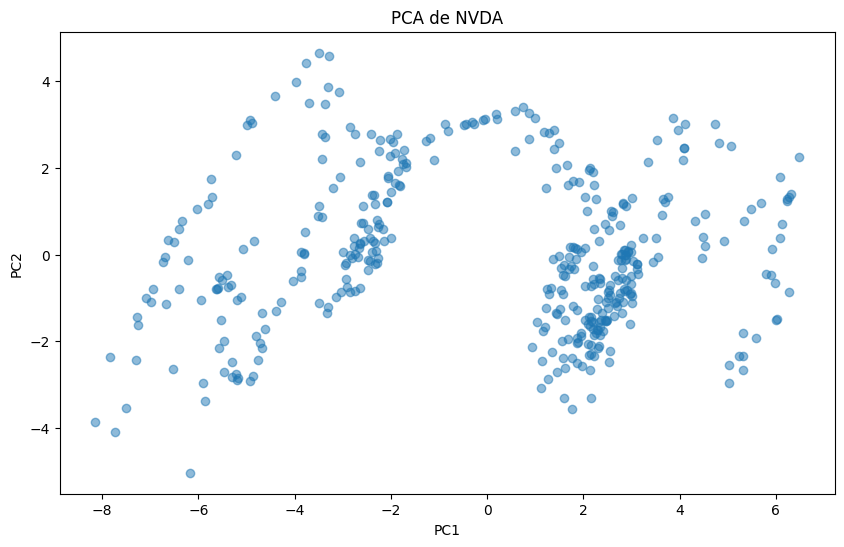

In [12]:
plt.figure(figsize=(10,6))

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    alpha=0.5
)

plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA de NVDA')
plt.show()

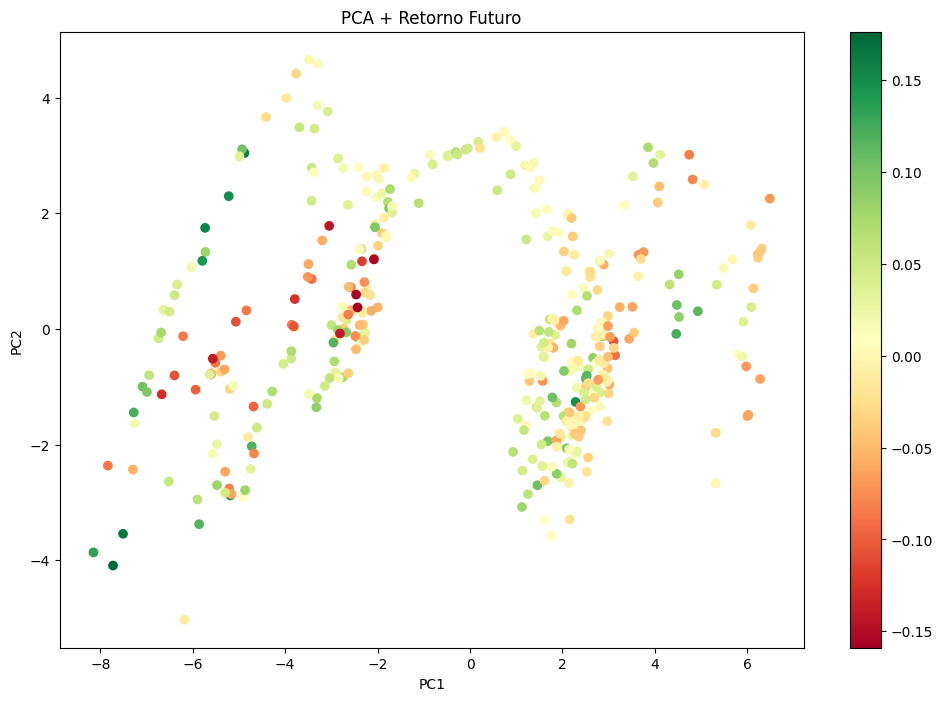

In [13]:
df['FutureReturn_5d'] = (
    df['Close'].shift(-5) / df['Close'] - 1
)

plt.figure(figsize=(12,8))

scatter = plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
    c=df.loc[X.index, 'FutureReturn_5d'],
    cmap='RdYlGn'
)

plt.colorbar(scatter)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA + Retorno Futuro')
plt.show()

In [14]:
print(var_exp.head(10))
print(loadings[['PC1','PC2','PC3']])

   PC  Varianza  Acumulada
0   1  0.602446   0.602446
1   2  0.151881   0.754327
2   3  0.079773   0.834099
3   4  0.067968   0.902067
4   5  0.044060   0.946128
5   6  0.033139   0.979267
6   7  0.011889   0.991156
7   8  0.005531   0.996688
8   9  0.002361   0.999049
9  10  0.000545   0.999594
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle        

In [15]:
print(loadings['PC1'].sort_values(key=abs, ascending=False))

Low                   0.279486
Cumulative_Returns    0.278952
Close                 0.278952
Open                  0.278861
High                  0.278649
MA_10                 0.278110
MA_20                 0.274724
BB_Middle             0.274724
BB_Upper              0.271860
BB_Lower              0.271038
MA_50                 0.259062
MA_100                0.233861
Volatility           -0.181082
Volume               -0.154773
Volume_Norm          -0.154773
MACD_Signal           0.129382
MACD                  0.120110
RSI                   0.038536
MACD_Hist            -0.005058
Returns               0.002210
BB_Std               -0.002013
Name: PC1, dtype: float64


In [16]:
print(loadings['PC2'].sort_values(key=abs, ascending=False))

RSI                   0.502371
MACD                  0.452456
MACD_Signal           0.361767
MACD_Hist             0.356866
MA_100               -0.220494
Volume_Norm          -0.217131
Volume               -0.217131
MA_50                -0.196502
Volatility           -0.149967
BB_Lower             -0.127193
Returns               0.118411
MA_20                -0.111943
BB_Middle            -0.111943
BB_Std                0.109895
BB_Upper             -0.093935
MA_10                -0.051727
Low                   0.025937
Cumulative_Returns    0.021310
Close                 0.021310
Open                  0.012764
High                  0.009203
Name: PC2, dtype: float64


In [17]:
print(loadings['PC3'].sort_values(key=abs, ascending=False))

BB_Std                0.615287
Volume_Norm           0.457177
Volume                0.457177
Volatility            0.277523
RSI                   0.150903
MACD                  0.141822
BB_Upper              0.129332
MACD_Signal           0.118557
Returns              -0.102249
MACD_Hist             0.096412
MA_100                0.084638
High                  0.072975
Open                  0.060946
MA_10                 0.060355
BB_Lower             -0.060349
Cumulative_Returns    0.051759
Close                 0.051759
Low                   0.037982
MA_20                 0.034653
BB_Middle             0.034653
MA_50                 0.016565
Name: PC3, dtype: float64


In [18]:
var_exp = pd.DataFrame({
    "Varianza": pca.explained_variance_ratio_,
    "Acumulada": pca.explained_variance_ratio_.cumsum()
})

print(var_exp.head(10))

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
5  0.033139   0.979267
6  0.011889   0.991156
7  0.005531   0.996688
8  0.002361   0.999049
9  0.000545   0.999594


In [19]:
print(var_exp.head(5))
print(loadings[['PC1','PC2','PC3']])

   Varianza  Acumulada
0  0.602446   0.602446
1  0.151881   0.754327
2  0.079773   0.834099
3  0.067968   0.902067
4  0.044060   0.946128
                         PC1       PC2       PC3
Close               0.278952  0.021310  0.051759
High                0.278649  0.009203  0.072975
Low                 0.279486  0.025937  0.037982
Open                0.278861  0.012764  0.060946
Volume             -0.154773 -0.217131  0.457177
Returns             0.002210  0.118411 -0.102249
MA_10               0.278110 -0.051727  0.060355
MA_20               0.274724 -0.111943  0.034653
MA_50               0.259062 -0.196502  0.016565
MA_100              0.233861 -0.220494  0.084638
Volatility         -0.181082 -0.149967  0.277523
Cumulative_Returns  0.278952  0.021310  0.051759
Volume_Norm        -0.154773 -0.217131  0.457177
BB_Middle           0.274724 -0.111943  0.034653
BB_Std             -0.002013  0.109895  0.615287
BB_Upper            0.271860 -0.093935  0.129332
BB_Lower            0.271038 

In [21]:
df_pca = pd.DataFrame(
    X_pca[:, :3],
    columns=['PC1','PC2','PC3'],
    index=X.index
)

df_pca['FutureReturn_5d'] = (
    df.loc[X.index, 'Close']
      .shift(-5)
      .div(df.loc[X.index, 'Close'])
      .sub(1)
)

df_pca.groupby(
    pd.qcut(df_pca['PC2'], 5)
)['FutureReturn_5d'].mean()

PC2
(-5.03, -1.529]     0.021163
(-1.529, -0.631]    0.007443
(-0.631, 0.174]    -0.004461
(0.174, 1.666]     -0.013596
(1.666, 4.656]      0.021241
Name: FutureReturn_5d, dtype: float64

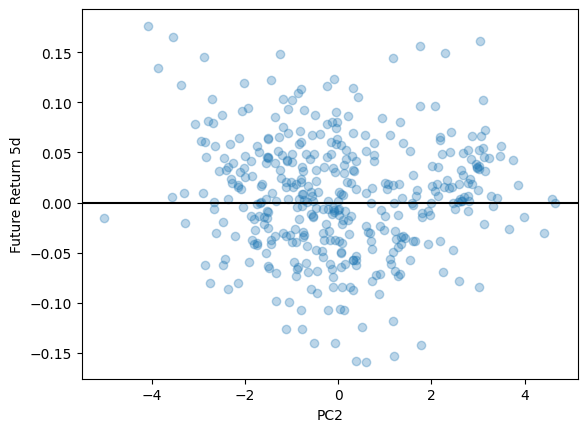

In [ ]:
plt.scatter(
    df_pca['PC2'],
    df_pca['FutureReturn_5d'],
    alpha=0.3
)

plt.axhline(0, color='black')
plt.xlabel("PC2")
plt.ylabel("Future Return 5d")
plt.show()

In [27]:
print(df_pca.groupby(
    pd.qcut(df_pca['PC3'], 5)
)['FutureReturn_5d'].mean())

PC3
(-2.533, -1.045]    0.016407
(-1.045, -0.578]    0.003590
(-0.578, 0.0313]    0.011605
(0.0313, 1.156]     0.002555
(1.156, 7.071]     -0.003054
Name: FutureReturn_5d, dtype: float64


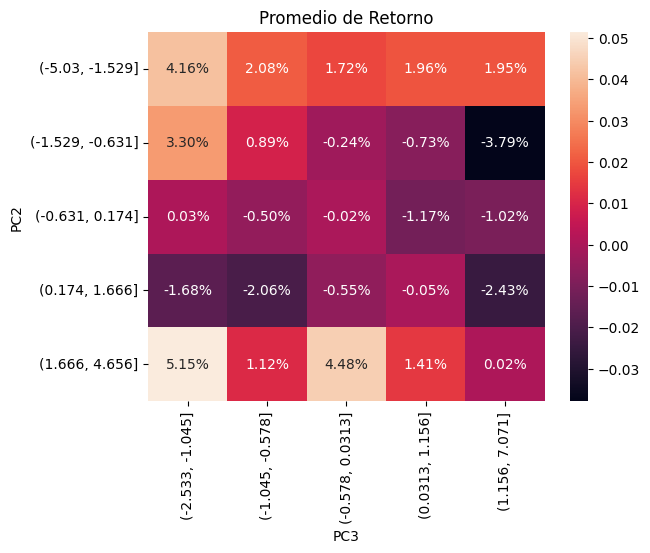

In [41]:
pivot = df_pca.pivot_table(
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='mean'
)

sns.heatmap(
    pivot,
    annot=True,
    fmt=".2%"
)
plt.title('Promedio de Retorno')
plt.show()

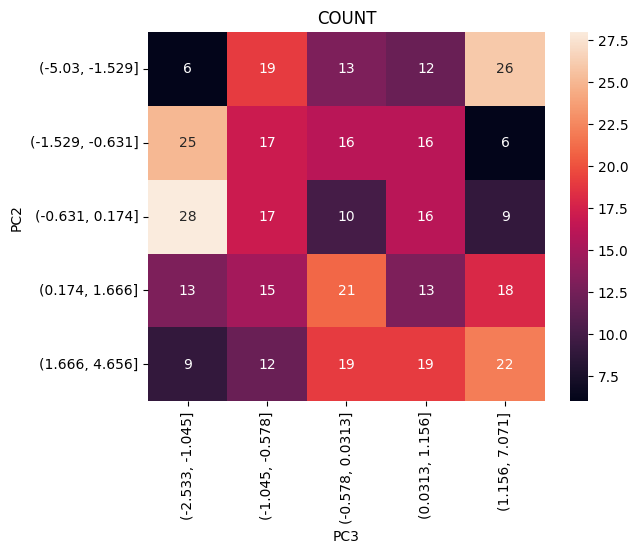

In [42]:
pivot_count = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='count'
)

sns.heatmap(
    pivot_count,
    annot=True,
    fmt='d'
)
plt.title('COUNT')
plt.show()

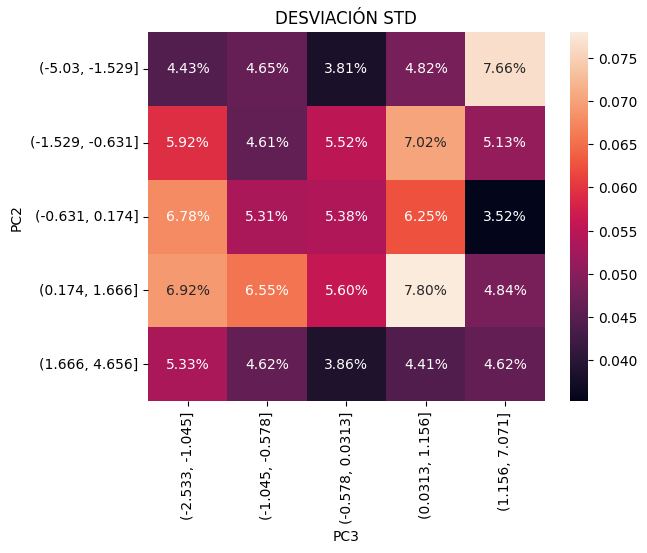

In [43]:
pivot_std = pd.pivot_table(
    df_pca,
    values='FutureReturn_5d',
    index=pd.qcut(df_pca['PC2'],5),
    columns=pd.qcut(df_pca['PC3'],5),
    aggfunc='std'
)

sns.heatmap(
    pivot_std,
    annot=True,
    fmt='.2%'
)
plt.title('DESVIACIÓN STD')
plt.show()

# **UMAP**

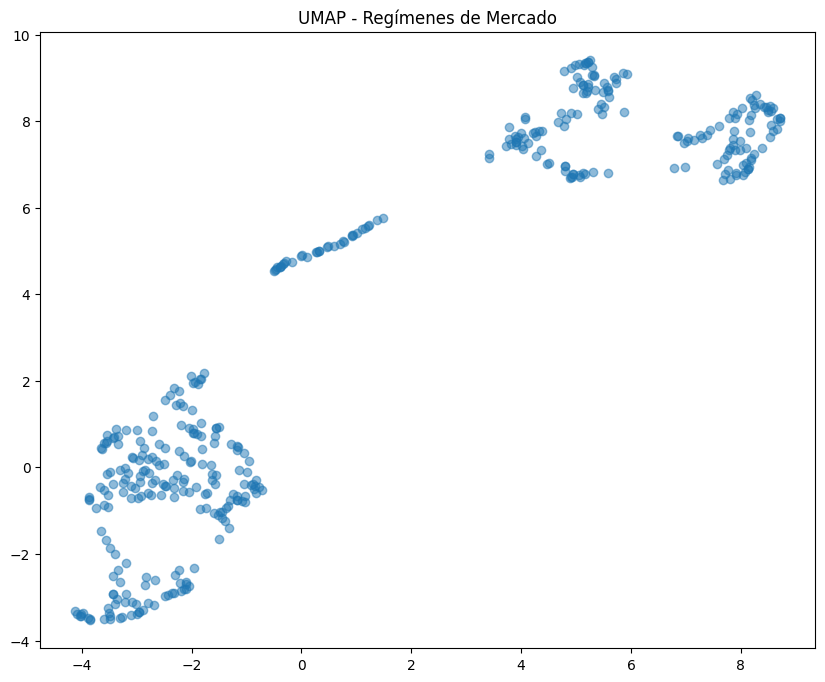

In [11]:
from sklearn.preprocessing import StandardScaler
import umap

X=df[features].dropna()
X_scaled=StandardScaler().fit_transform(X)

reducer = umap.UMAP(
    n_neighbors=30,
    min_dist=0.1,
    random_state=42
)

embedding = reducer.fit_transform(X_scaled)


plt.figure(figsize=(10,8))

plt.scatter(
    embedding[:,0],
    embedding[:,1],
    alpha=0.5
)

plt.title("UMAP - Regímenes de Mercado")
plt.show()

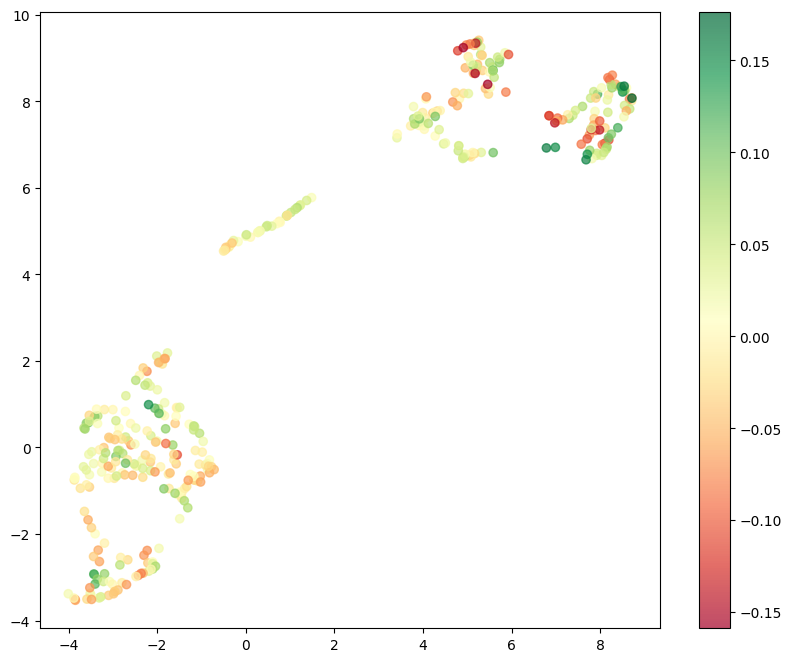

In [8]:
df_umap = pd.DataFrame(
    embedding,
    columns=['UMAP1','UMAP2'],
    index=X.index
)

df_umap['FutureReturn_5d'] = (
    df.loc[X.index,'Close']
      .shift(-5)
      .div(df.loc[X.index,'Close'])
      .sub(1)
)

plt.figure(figsize=(10,8))

scatter = plt.scatter(
    df_umap['UMAP1'],
    df_umap['UMAP2'],
    c=df_umap['FutureReturn_5d'],
    cmap='RdYlGn',
    alpha=0.7
)

plt.colorbar(scatter)
plt.show()

In [12]:
from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(embedding)

df_umap["Cluster"] = clusters

In [14]:
print(df_umap.groupby("Cluster")["FutureReturn_5d"].agg(
    ["count","mean","std"]
))

         count      mean       std
Cluster                           
0           89  0.000241  0.059945
1          151  0.008476  0.045199
2           71  0.011276  0.087138
3           51 -0.005374  0.054325
4           34  0.015958  0.028457


In [15]:
cluster_stats = (
    df_umap
    .join(df[features])
    .groupby("Cluster")[features]
    .mean()
)

print(cluster_stats)

              Close        High         Low        Open        Volume  \
Cluster                                                                 
0        139.741802  141.898499  137.474125  139.897385  2.164523e+08   
1        181.983214  184.527543  179.414686  182.104982  1.812415e+08   
2        116.276864  118.905730  113.201158  116.141403  2.965222e+08   
3        207.225460  210.723834  203.779432  207.540616  1.697519e+08   
4        172.366311  173.886345  170.172175  172.096083  1.582842e+08   

          Returns       MA_10       MA_20       MA_50      MA_100  ...  \
Cluster                                                            ...   
0        0.003660  137.840472  135.716489  129.710298  126.081448  ...   
1        0.001429  181.784664  182.294544  181.546412  175.001954  ...   
2       -0.001833  117.781200  120.033051  126.055523  131.292936  ...   
3       -0.000080  205.680089  201.152413  190.910597  185.912940  ...   
4        0.005211  168.382617  163.393398  1

In [21]:
from scipy.stats import ttest_ind

c4 = df_umap[df_umap.Cluster==4]["FutureReturn_5d"]
resto = df_umap[df_umap.Cluster!=4]["FutureReturn_5d"]

c4 = c4.dropna()
resto = resto.dropna()

# Prueba parametrica
t_stat, p_value = ttest_ind(
    c4,
    resto,
    equal_var=False
)

print("p-value", p_value)

# Prueba no parametrica
from scipy.stats import mannwhitneyu

stat, p = mannwhitneyu(
    c4,
    resto,
    alternative='two-sided'
)

print("p-value:", p)

p-value 0.0653331606826222
p-value: 0.18989358287696811


In [22]:
print(c4.describe())
print(resto.describe())

count    34.000000
mean      0.015958
std       0.028457
min      -0.041057
25%       0.000003
50%       0.014195
75%       0.041882
max       0.066875
Name: FutureReturn_5d, dtype: float64
count    362.000000
mean       0.005049
std        0.060328
min       -0.158904
25%       -0.036026
50%        0.003454
75%        0.044557
max        0.176227
Name: FutureReturn_5d, dtype: float64


In [23]:
print("Cluster 4:", (c4 > 0).mean())
print("Resto:", (resto > 0).mean())

Cluster 4: 0.7352941176470589
Resto: 0.5414364640883977


# **NearestNeighbors**

In [6]:
import sys
import os

# Agregamos la carpeta Scripts al path de búsqueda de Python
ruta_scripts = r'D:\Github-Time\financial-time-series-lab\Scripts'
if ruta_scripts not in sys.path:
    sys.path.append(ruta_scripts)

# Ahora ya debería encontrarlo
from dowload_stocks import obtener_datos, agregar_indicadores

def ejecutar_analisis(ticker, periodo):
    print(f"--- Procesando {ticker} para el periodo {periodo} ---")
    
    # 1. Obtener datos
    df = obtener_datos(ticker, periodo)
    
    # 2. Agregar indicadores
    df = agregar_indicadores(df)
    
    return df

df=ejecutar_analisis(ticker='SPY',periodo='2y')
df

--- Procesando SPY para el periodo 2y ---


[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume,Returns,MA_10,MA_20,MA_50,Volatility,BB_Middle,BB_Std,BB_Upper,BB_Lower,RSI,MACD,MACD_Signal
Date,,,,,,,,,,,,,,,,,
2024-06-17,534.101562,535.497640,528.742008,529.200872,55839500,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000,0.000000
2024-06-18,535.458557,535.585473,533.740363,534.160140,41376400,0.002541,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.108250,0.021650
2024-06-20,534.003967,537.049835,532.227201,536.385998,70328200,-0.002717,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.075792,0.032479
2024-06-21,533.288147,534.404667,531.828864,533.180428,64338600,-0.001340,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.007604,0.024462
2024-06-24,531.554443,535.677699,531.436921,533.111701,45528700,-0.003251,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.211157,-0.022662
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-06-09,737.049988,746.900024,722.590027,743.630005,87683500,-0.002936,750.479993,746.260495,717.453599,0.008088,746.260495,8.326565,762.913624,729.607366,52.878947,7.025799,10.510735
2026-06-10,725.429993,738.380005,725.330017,733.390015,60341300,-0.015766,747.976990,745.622995,719.322799,0.008813,745.622995,9.397057,764.417110,726.828880,37.192366,4.873232,9.383235
2026-06-11,737.760010,740.000000,724.409973,728.760010,86330500,0.016997,746.292993,745.395496,721.071199,0.009586,745.395496,9.535542,764.466579,726.324412,46.584995,4.114805,8.329549


Hoy el régimen es 1
Regímenes de los 10 días más parecidos: [1 1 1 1 1 1 0 1 0 1]
Price     Returns       Vol      Mean      Skew
Regimen                                        
0        0.002647  0.007433  0.001910  0.050466
1       -0.002404  0.008849 -0.000597 -0.751763
2        0.006512  0.032688 -0.000277  1.440718


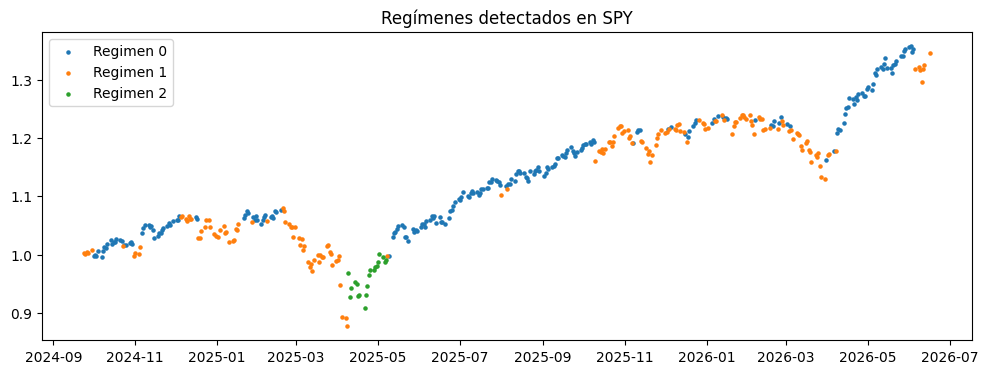

In [22]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt

# Asumo df: index=fecha, columna 'Returns'
df = df.dropna(subset=['Returns']).copy()

# 1. Crea features por día: qué describe el "régimen" de ese día
window = 20
df['Vol'] = df['Returns'].rolling(window).std() # Volatilidad
df['Mean'] = df['Returns'].rolling(window).mean() # Drift
df['Skew'] = df['Returns'].rolling(window).skew() # Asimetría
df = df.dropna()

# 2. Matriz X: cada fila = 1 día, columnas = features del régimen
features = ['Returns', 'Vol', 'Mean', 'Skew']
X = df[features].values
X_scaled = StandardScaler().fit_transform(X)

# 3. KMeans para crear los regímenes: ej. 3 grupos
n_regimenes = 3
kmeans = KMeans(n_clusters=n_regimenes, n_init=10, random_state=42)
df['Regimen'] = kmeans.fit_predict(X_scaled)

# 4. Ahora sí usas KNN: para etiquetar días nuevos rápido
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X_scaled, df['Regimen'].values) # le pasamos las etiquetas

# Ejemplo: clasifico el último día viendo sus 10 vecinos
dist, idx = knn.kneighbors(X_scaled[-1].reshape(1, -1))
vecinos_regimen = df['Regimen'].iloc[idx[0]]
regimen_hoy = vecinos_regimen.mode()[0] # voto mayoritario

print(f"Hoy el régimen es {regimen_hoy}")
print(f"Regímenes de los 10 días más parecidos: {vecinos_regimen.values}")

# 5. Visualiza para entender qué capturó cada régimen
print(df.groupby('Regimen')[features].mean())
df['Close'] = (1 + df['Returns']).cumprod() # precio simulado
plt.figure(figsize=(12,4))
for r in range(n_regimenes):
    mask = df['Regimen'] == r
    plt.scatter(df.index[mask], df['Close'][mask], s=5, label=f'Regimen {r}')
plt.legend()
plt.title('Regímenes detectados en SPY')
plt.show()

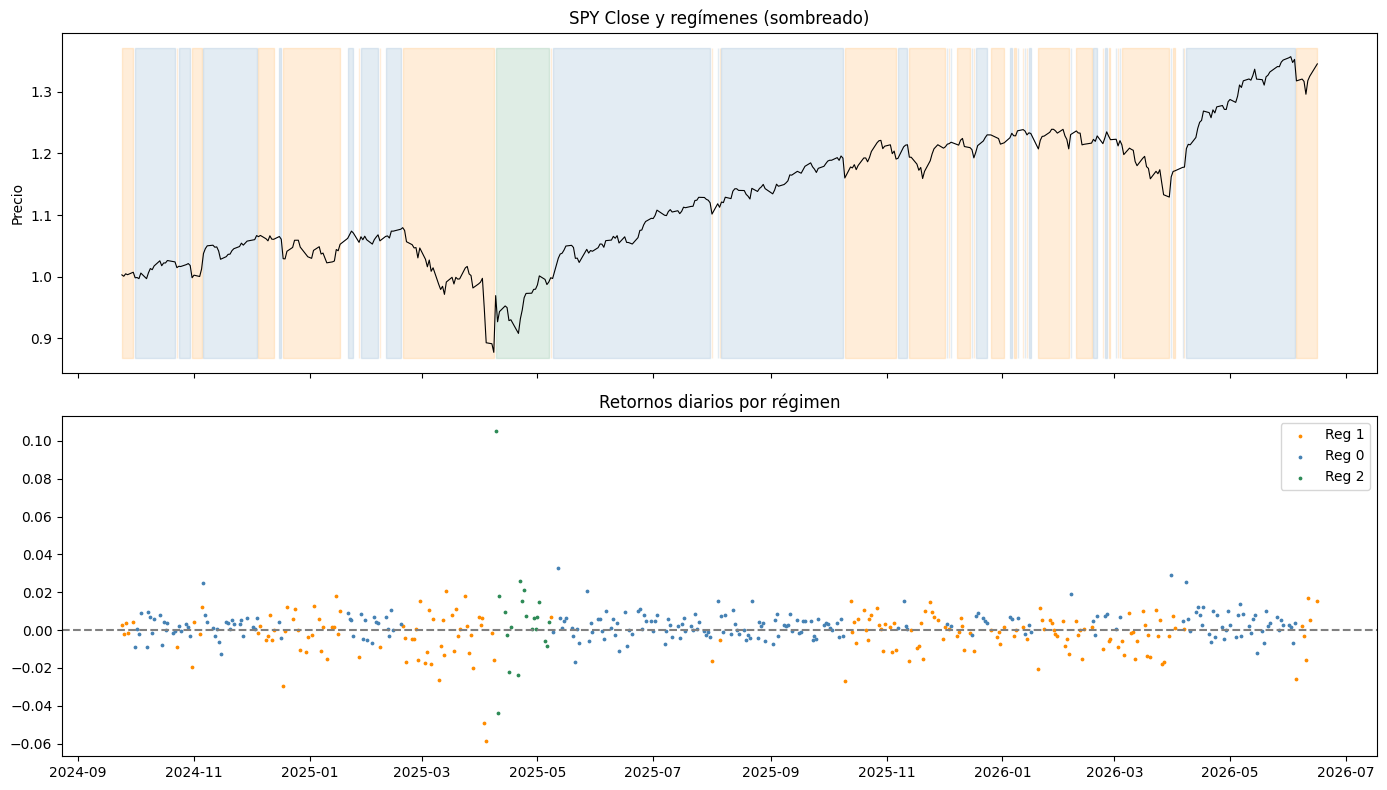

In [ ]:
# Serie temporal de regímenes con precio y retornos 

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14,8), sharex=True)

# Precio de cierre con fondo de color por régimen
colors = {0:'steelblue', 1:'darkorange', 2:'seagreen'}
for r in df['Regimen'].unique():
    mask = df['Regimen'] == r
    ax1.fill_between(df.index, df['Close'].min()*0.99, df['Close'].max()*1.01,
                     where=mask, color=colors.get(r, 'gray'), alpha=0.15)
ax1.plot(df.index, df['Close'], color='black', lw=0.8)
ax1.set_title('SPY Close y regímenes (sombreado)')
ax1.set_ylabel('Precio')

# Retornos diarios coloreados por régimen
for r in df['Regimen'].unique():
    mask = df['Regimen'] == r
    ax2.scatter(df.index[mask], df['Returns'][mask], s=3, color=colors.get(r), label=f'Reg {r}')
ax2.axhline(0, color='gray', ls='--')
ax2.set_title('Retornos diarios por régimen')
ax2.legend()
plt.tight_layout()
plt.show()

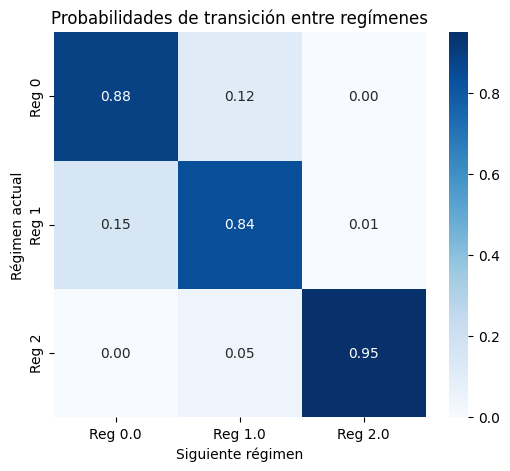

In [ ]:
# 2. Matriz de transición entre regímenes

from pandas import crosstab

# Calcular transiciones
df['Regimen_next'] = df['Regimen'].shift(-1)
trans_mat = crosstab(df['Regimen'], df['Regimen_next'], normalize='index')

# Heatmap
import seaborn as sns
plt.figure(figsize=(6,5))
sns.heatmap(trans_mat, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=[f'Reg {i}' for i in trans_mat.columns],
            yticklabels=[f'Reg {i}' for i in trans_mat.index])
plt.title('Probabilidades de transición entre regímenes')
plt.xlabel('Siguiente régimen')
plt.ylabel('Régimen actual')
plt.show()

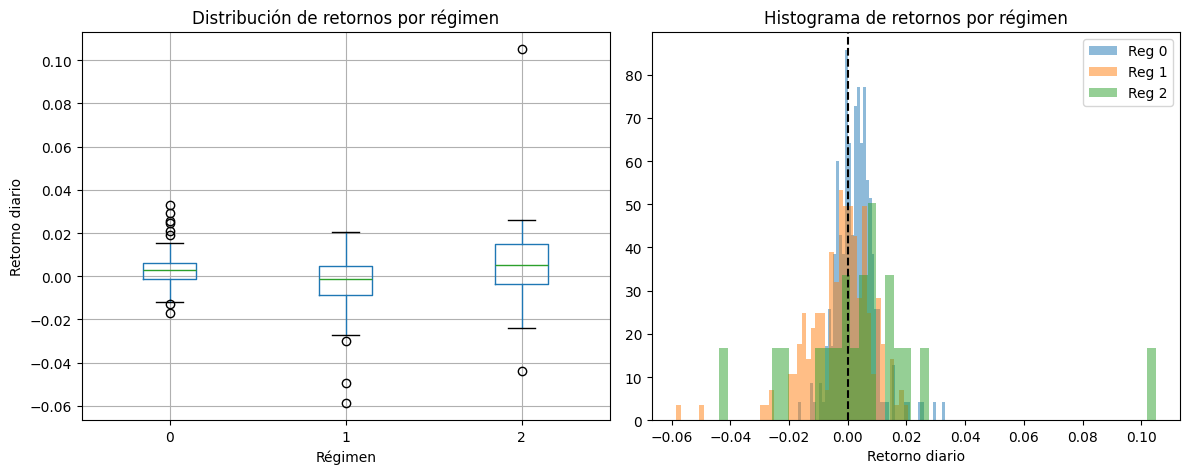

In [ ]:
# 3. Distribución condicional de retornos por régimen (boxplot + histograma)

fig, axes = plt.subplots(1, 2, figsize=(12,5))

# Boxplot
df.boxplot(column='Returns', by='Regimen', ax=axes[0])
axes[0].set_title('Distribución de retornos por régimen')
axes[0].set_xlabel('Régimen')
axes[0].set_ylabel('Retorno diario')

# Histograma overlay
for r in sorted(df['Regimen'].unique()):
    axes[1].hist(df.loc[df['Regimen']==r, 'Returns'], bins=50, alpha=0.5,
                 label=f'Reg {r}', density=True)
axes[1].axvline(0, color='black', ls='--')
axes[1].legend()
axes[1].set_title('Histograma de retornos por régimen')
axes[1].set_xlabel('Retorno diario')
plt.suptitle('')
plt.tight_layout()
plt.show()

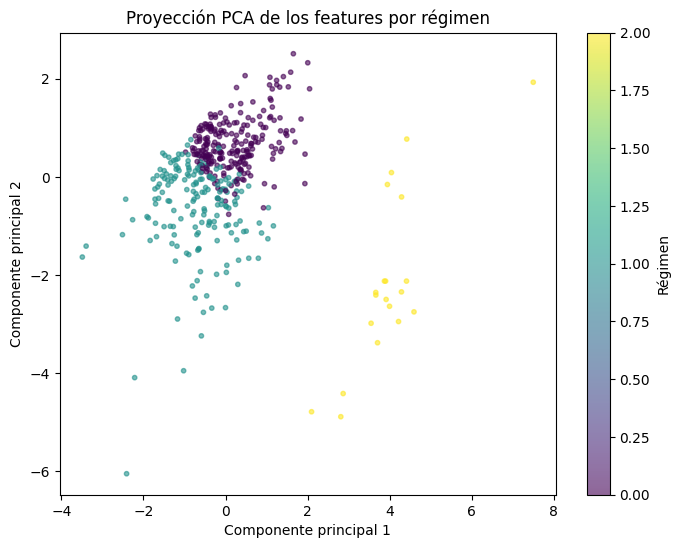

In [26]:
# 4. Visualización de clusters (PCA o t‑SNE)
from sklearn.decomposition import PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=df['Regimen'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(scatter, label='Régimen')
plt.xlabel('Componente principal 1')
plt.ylabel('Componente principal 2')
plt.title('Proyección PCA de los features por régimen')
plt.show()

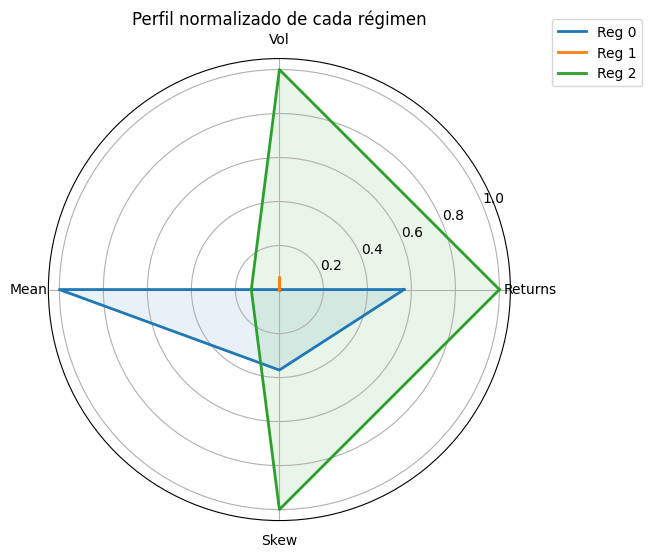

In [ ]:
# 5. Radar / spider chart de las características promedio de cada régimen

from math import pi

features_radar = ['Returns', 'Vol', 'Mean', 'Skew']
means = df.groupby('Regimen')[features_radar].mean()
# Normalizar para llevarlo a escala 0-1 (para el radar)
means_norm = (means - means.min()) / (means.max() - means.min())

categories = features_radar
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(6,6), subplot_kw=dict(polar=True))
for idx, row in means_norm.iterrows():
    values = row.values.flatten().tolist()
    values += values[:1]
    ax.plot(angles, values, linewidth=2, linestyle='solid', label=f'Reg {idx}')
    ax.fill(angles, values, alpha=0.1)
ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories)
ax.set_title('Perfil normalizado de cada régimen')
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
plt.show()

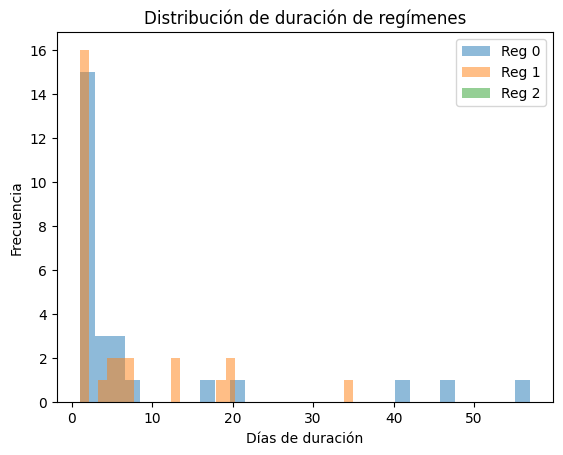

In [28]:
# Identificar rachas
df['regime_change'] = (df['Regimen'] != df['Regimen'].shift(1)).astype(int)
df['streak_id'] = df['regime_change'].cumsum()
streaks = df.groupby(['Regimen', 'streak_id']).size().reset_index(name='duration')

for r in sorted(df['Regimen'].unique()):
    plt.hist(streaks.loc[streaks['Regimen']==r, 'duration'], bins=30, alpha=0.5, label=f'Reg {r}')
plt.legend()
plt.xlabel('Días de duración')
plt.ylabel('Frecuencia')
plt.title('Distribución de duración de regímenes')
plt.show()

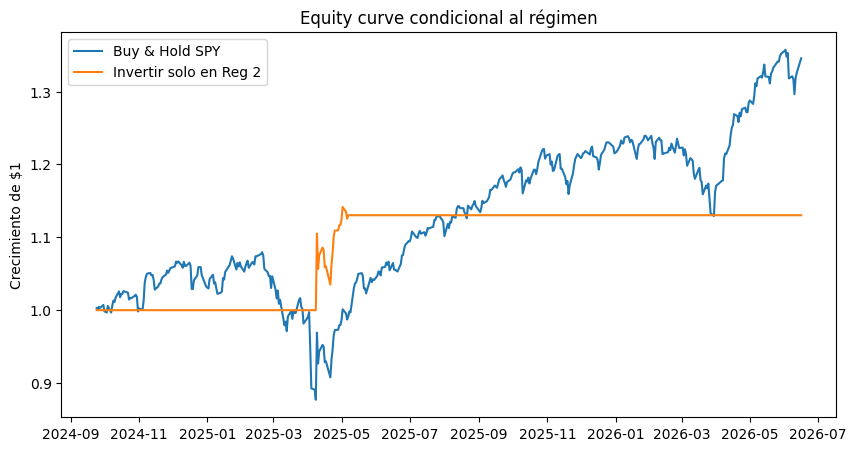

In [29]:
# Definir regímenes "largos" vs "cortos" a ojo (o por retorno medio)
# Ej: régimen con retorno medio más alto
mean_ret = df.groupby('Regimen')['Returns'].mean()
best_reg = mean_ret.idxmax()

df['strat_ret'] = np.where(df['Regimen'] == best_reg, df['Returns'], 0)
df['bench_ret'] = df['Returns']

cum_bench = (1 + df['bench_ret']).cumprod()
cum_strat = (1 + df['strat_ret']).cumprod()

plt.figure(figsize=(10,5))
plt.plot(df.index, cum_bench, label='Buy & Hold SPY')
plt.plot(df.index, cum_strat, label=f'Invertir solo en Reg {best_reg}')
plt.title('Equity curve condicional al régimen')
plt.legend()
plt.ylabel('Crecimiento de $1')
plt.show()

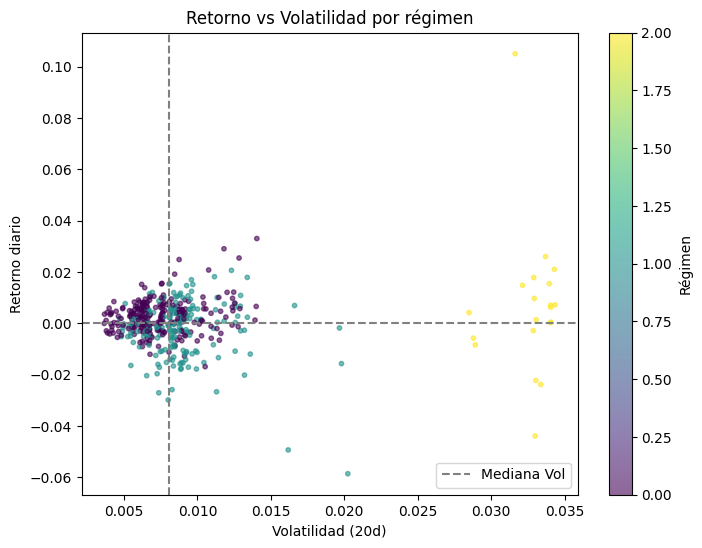

In [30]:
plt.figure(figsize=(8,6))
sc = plt.scatter(df['Vol'], df['Returns'], c=df['Regimen'], cmap='viridis', s=10, alpha=0.6)
plt.colorbar(sc, label='Régimen')
plt.xlabel('Volatilidad (20d)')
plt.ylabel('Retorno diario')
plt.title('Retorno vs Volatilidad por régimen')
plt.axhline(0, color='gray', ls='--')
plt.axvline(df['Vol'].median(), color='gray', ls='--', label='Mediana Vol')
plt.legend()
plt.show()

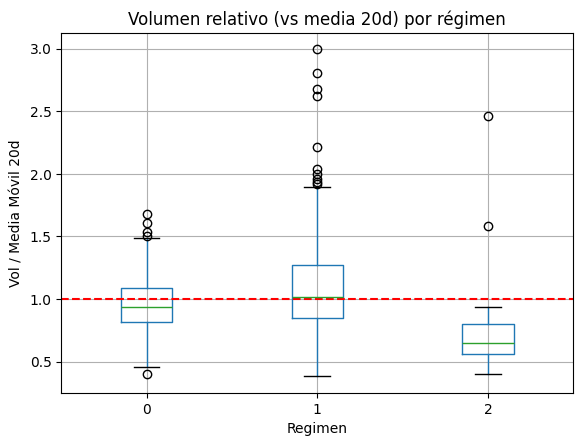

In [31]:
df['Volume_norm'] = df['Volume'] / df['Volume'].rolling(20).mean()  # ratio vs media móvil
df.boxplot(column='Volume_norm', by='Regimen')
plt.title('Volumen relativo (vs media 20d) por régimen')
plt.suptitle('')
plt.ylabel('Vol / Media Móvil 20d')
plt.axhline(1, color='red', ls='--')
plt.show()

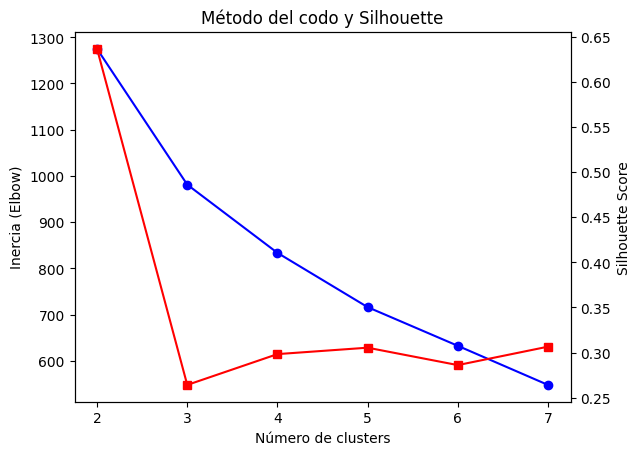

In [32]:
from sklearn.metrics import silhouette_score

inertias = []
sil_scores = []
K_range = range(2, 8)
for k in K_range:
    km = KMeans(n_clusters=k, n_init=10, random_state=42)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    sil_scores.append(silhouette_score(X_scaled, labels))

fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(K_range, inertias, 'bo-')
ax1.set_xlabel('Número de clusters')
ax1.set_ylabel('Inercia (Elbow)')
ax2.plot(K_range, sil_scores, 'rs-')
ax2.set_ylabel('Silhouette Score')
plt.title('Método del codo y Silhouette')
plt.show()

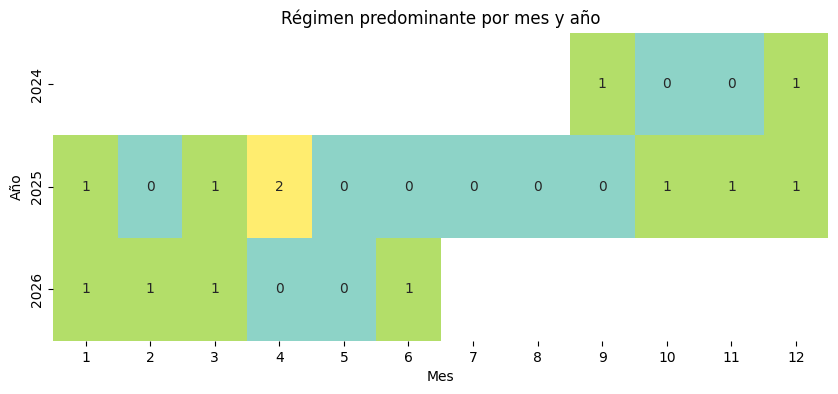

In [34]:
df['year'] = df.index.year
df['month'] = df.index.month
pivot = df.pivot_table(index='year', columns='month', values='Regimen', aggfunc=lambda x: x.mode().iloc[0])

plt.figure(figsize=(10,4))
sns.heatmap(pivot, annot=True, cmap='Set3', cbar=False)
plt.title('Régimen predominante por mes y año')
plt.xlabel('Mes')
plt.ylabel('Año')
plt.show()

Text(0.5, 1.0, 'Regímenes detectados en SPY')

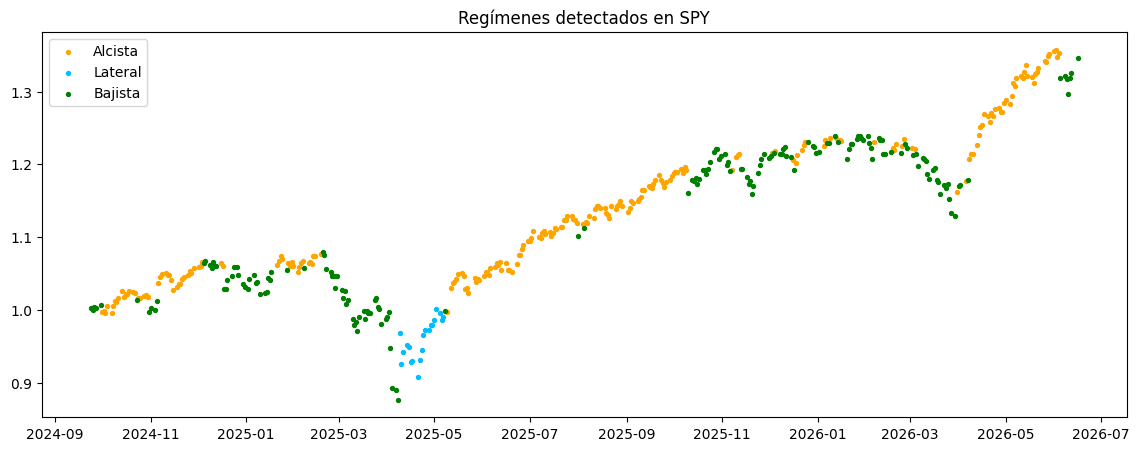

In [36]:
# Después del fit de KMeans
resumen = df.groupby('Regimen')['Mean'].mean().sort_values()
mapa = {resumen.index[0]: 'Bajista',
        resumen.index[1]: 'Lateral',
        resumen.index[2]: 'Alcista'}
df['Regimen_Nombre'] = df['Regimen'].map(mapa)

# Ahora el plot con nombres y colores fijos
colores = {'Alcista': 'orange', 'Lateral': 'deepskyblue', 'Bajista': 'green'}
plt.figure(figsize=(14,5))
for nombre, color in colores.items():
    mask = df['Regimen_Nombre'] == nombre
    plt.scatter(df.index[mask], df['Close'][mask], s=8, c=color, label=nombre)
plt.legend()
plt.title('Regímenes detectados en SPY')

In [20]:
import numpy as np
from sklearn.preprocessing import StandardScaler

# 1. Guarda el scaler que usaste para entrenar. Importante: no hagas fit de nuevo
scaler = StandardScaler().fit(X) # X es tu matriz de entrenamiento original
X_scaled = scaler.transform(X)

# 2. Re-entrena KNN con X_scaled para que todo esté en la misma escala
knn = NearestNeighbors(n_neighbors=10)
knn.fit(X_scaled)

# 3. Para clasificar "hoy" o el último día de tu df
window = 20
ultimos_20 = df['Returns'].iloc[-window:]

nueva_fila_features = [
    df['Returns'].iloc[-1], # Return de hoy
    ultimos_20.std(), # Vol de 20d
    ultimos_20.mean(), # Mean de 20d
    ultimos_20.skew() # Skew de 20d
]

# 4. Escala con el mismo scaler y predice
nuevo_X = scaler.transform([nueva_fila_features])
dist, idx = knn.kneighbors(nuevo_X)
regimen_predicho = df['Regimen_Nombre'].iloc[idx[0]].mode()[0]

print(f"Régimen predicho para hoy: {regimen_predicho}")
print(f"Basado en estos 10 días históricos: {df.index[idx[0]].date}")

Régimen predicho para hoy: Bajista
Basado en estos 10 días históricos: [datetime.date(2026, 6, 16) datetime.date(2024, 9, 19)
 datetime.date(2024, 11, 5) datetime.date(2026, 6, 11)
 datetime.date(2024, 9, 11) datetime.date(2026, 1, 21)
 datetime.date(2024, 9, 12) datetime.date(2025, 10, 20)
 datetime.date(2024, 9, 9) datetime.date(2025, 10, 27)]


In [19]:
def clasificar_dia_actual(df, features, scaler, knn_model, window=20):
    ultimos = df['Returns'].iloc[-window:]
    nueva_fila = [
        df['Returns'].iloc[-1],
        ultimos.std(),
        ultimos.mean(),
        ultimos.skew()
    ]
    nuevo_X = scaler.transform([nueva_fila])
    _, idx = knn_model.kneighbors(nuevo_X)
    return df['Regimen_Nombre'].iloc[idx[0]].mode()[0]

# Uso:
regimen_hoy = clasificar_dia_actual(df, features, scaler, knn)
print(regimen_hoy)

Bajista
